<a href="https://colab.research.google.com/github/careervrosterm/algorithm-portfolio/blob/main/API%20Earthquake%20Scraper%20and%20Heat%20Map.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import requests
import time
from bs4 import BeautifulSoup
import geopandas as gpd

### Data Source 1
The following request collects data from the USGS' database regarding earthquakes in the United States over the last month. Thi table is then split into "high" magnitude events that are at or above a 3 on the Richter scale, and "low" magnitude events that are below 3. Most earthquakes in this low magnitude category are normally not damaging, last for a short durationn, and only occur in a small radius.

In [ ]:
response = requests.get("https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2024-10-01&minlongitude=-140&maxlongitude=-50&minlatitude=22&maxlatitude=52")


In [ ]:
df_eq = pd.json_normalize(response.json(), 'features')

# converting time from milliseconds from 1970 to year
df_eq["year"] = df_eq["properties.time"] // 31536000000 + 1970

df_low_magnitude = df_eq[(df_eq["properties.mag"] < 3.0) & (df_eq["properties.mag"] >= 1)]
df_high_magnitude = df_eq[df_eq["properties.mag"] >= 3.0]
df_low_magnitude

,type,id,properties.mag,properties.place,properties.time,properties.updated,properties.tz,properties.url,properties.detail,properties.felt,...,properties.nst,properties.dmin,properties.rms,properties.gap,properties.magType,properties.type,properties.title,geometry.type,geometry.coordinates,year
0,Feature,nn00887485,1.40,"14 km E of Graniteville, California",1731459851305,1731459979272,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,10,0.20700,0.3277,152.16,ml,earthquake,"M 1.4 - 14 km E of Graniteville, California",Point,"[-120.5746, 39.4165, 0]",2024
2,Feature,nn00887482,1.60,"20 km E of Sparks, Nevada",1731458427500,1731458549351,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,10,0.28200,0.1240,90.08,ml,earthquake,"M 1.6 - 20 km E of Sparks, Nevada",Point,"[-119.5124, 39.5262, 0.9]",2024
4,Feature,ci40792231,1.22,"3 km ESE of Loma Linda, CA",1731457484970,1731457879756,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,46,0.09754,0.1600,45.00,ml,earthquake,"M 1.2 - 3 km ESE of Loma Linda, CA",Point,"[-117.2298333, 34.0331667, 12.52]",2024
5,Feature,ci40792215,1.50,"5 km NNW of Boron, CA",1731456917120,1731457301864,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,36,0.10990,0.2000,60.00,ml,earthquake,"M 1.5 - 5 km NNW of Boron, CA",Point,"[-117.6668333, 35.0418333, -0.79]",2024
6,Feature,nn00887473,1.00,"28 km NW of Furnace Creek, California",1731456878375,1731456999305,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,13,0.34100,0.2931,178.40,ml,earthquake,"M 1.0 - 28 km NW of Furnace Creek, California",Point,"[-117.1125, 36.6008, 9.1]",2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6199,Feature,tx2024tgsg,1.70,"56 km S of Whites City, New Mexico",1727744732026,1727793971935,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,19,0.00000,0.1000,88.00,ml,earthquake,"M 1.7 - 56 km S of Whites City, New Mexico",Point,"[-104.413, 31.671, 6.3049]",2024
6201,Feature,ci40749311,1.23,"20 km ESE of Little Lake, CA",1727744239290,1727790692750,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,28,0.06491,0.1100,43.00,ml,earthquake,"M 1.2 - 20 km ESE of Little Lake, CA",Point,"[-117.688, 35.8905, 9.22]",2024
6203,Feature,nm60592111,1.37,"3 km NW of Ridgely, Tennessee",1727743575060,1727805472000,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,21,0.03432,0.0400,43.00,md,earthquake,"M 1.4 - 3 km NW of Ridgely, Tennessee",Point,"[-89.5135, 36.2903333333333, 8.78]",2024
6204,Feature,ci40749303,1.00,"11 km N of Borrego Springs, CA",1727743500660,1727798402376,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,58,0.02866,0.2000,30.00,ml,earthquake,"M 1.0 - 11 km N of Borrego Springs, CA",Point,"[-116.3751667, 33.3546667, 11.31]",2024


In [ ]:
df_high_magnitude

,type,id,properties.mag,properties.place,properties.time,properties.updated,properties.tz,properties.url,properties.detail,properties.felt,...,properties.nst,properties.dmin,properties.rms,properties.gap,properties.magType,properties.type,properties.title,geometry.type,geometry.coordinates,year
135,Feature,tx2024weow,3.10,"39 km NW of Toyah, Texas",1731332606846,1731428183040,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,NaN,...,26,0.000000,0.20,63.0,ml,earthquake,"M 3.1 - 39 km NW of Toyah, Texas",Point,"[-104.096, 31.561, 6.1639]",2024
182,Feature,nc75085161,3.12,"26 km SE of Rio Dell, CA",1731303319290,1731403632040,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,4.0,...,41,0.030980,0.14,52.0,ml,earthquake,"M 3.1 - 26 km SE of Rio Dell, CA",Point,"[-123.827163696289, 40.3958320617676, 30.23999...",2024
217,Feature,ci40791447,3.56,"20 km NW of Desert Center, CA",1731275601370,1731362149386,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,88.0,...,72,0.178300,0.17,38.0,ml,earthquake,"M 3.6 - 20 km NW of Desert Center, CA",Point,"[-115.5245, 33.8585, 4.64]",2024
379,Feature,us7000nqv6,3.20,"12 km S of Atoka, New Mexico",1731147860728,1731157358166,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,1.0,...,37,0.497000,0.38,100.0,ml,earthquake,"M 3.2 - 12 km S of Atoka, New Mexico",Point,"[-104.3953, 32.6584, 9.036]",2024
647,Feature,ci40789191,3.46,"4 km ENE of Stovepipe Wells, CA",1730980410120,1731326266608,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,7.0,...,18,0.399000,0.14,146.0,ml,earthquake,"M 3.5 - 4 km ENE of Stovepipe Wells, CA",Point,"[-117.1035, 36.6175, 0.77]",2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5942,Feature,us7000nhqw,4.20,"266 km SW of Port McNeill, Canada",1727883345347,1731372667040,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,7.0,...,68,0.940000,1.37,89.0,mb,earthquake,"M 4.2 - 266 km SW of Port McNeill, Canada",Point,"[-129.5695, 48.8116, 10]",2024
6050,Feature,nc75069216,3.08,"11 km NNW of Avenal, CA",1727834776790,1730949373040,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,2.0,...,58,0.049610,0.13,49.0,ml,earthquake,"M 3.1 - 11 km NNW of Avenal, CA",Point,"[-120.201666666667, 36.0833333333333, 11.4]",2024
6059,Feature,nc75069176,4.02,"11 km NNW of Avenal, CA",1727829918260,1731040189473,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,53.0,...,71,0.047660,0.17,36.0,mw,earthquake,"M 4.0 - 11 km NNW of Avenal, CA",Point,"[-120.200666666667, 36.0808333333333, 11.15]",2024
6091,Feature,ci40749799,3.54,"2 km SE of Ontario, CA",1727812581570,1729555034500,None,https://earthquake.usgs.gov/earthquakes/eventp...,https://earthquake.usgs.gov/fdsnws/event/1/que...,1383.0,...,150,0.006642,0.19,13.0,ml,earthquake,"M 3.5 - 2 km SE of Ontario, CA",Point,"[-117.608, 34.0398333, 5.29]",2024


### Data Source 2
The second data source is simple; it's a recent map of the United States mainland. This was pulled from the Day 12 notebook that used this for football stadium locations. While state boundaries aren't very relevant for plotting earthquake locations, they are kept in for ease of location on the visual below.

In [ ]:
# US Map Files
zipfile = "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_state_500k.zip"

df_states = gpd.read_file(zipfile)
df_states

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,28,01779790,0400000US28,28,MS,Mississippi,00,121533519481,3926919758,"MULTIPOLYGON (((-88.50297 30.21524, -88.49176 ..."
1,37,01027616,0400000US37,37,NC,North Carolina,00,125923656064,13466071395,"MULTIPOLYGON (((-75.72681 35.93584, -75.71827 ..."
2,40,01102857,0400000US40,40,OK,Oklahoma,00,177662925723,3374587997,"POLYGON ((-103.00256 36.52659, -103.00219 36.6..."
3,51,01779803,0400000US51,51,VA,Virginia,00,102257717110,8528531774,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ..."
4,54,01779805,0400000US54,54,WV,West Virginia,00,62266474513,489028543,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,..."
5,22,01629543,0400000US22,22,LA,Louisiana,00,111897594374,23753621895,"MULTIPOLYGON (((-88.8677 29.86155, -88.86566 2..."
6,26,01779789,0400000US26,26,MI,Michigan,00,146600952990,103885855702,"MULTIPOLYGON (((-83.19159 42.03537, -83.18993 ..."
7,25,00606926,0400000US25,25,MA,Massachusetts,00,20205125364,7129925486,"MULTIPOLYGON (((-70.23405 41.28565, -70.22361 ..."
8,16,01779783,0400000US16,16,ID,Idaho,00,214049787659,2391722557,"POLYGON ((-117.24267 44.39655, -117.23484 44.3..."
9,12,00294478,0400000US12,12,FL,Florida,00,138949136250,31361101223,"MULTIPOLYGON (((-80.17628 25.52505, -80.17395 ..."


## Earthquakes of Low Magnitude: 10.01.24 to Current

<ipython-input-31-3bb895a8a0ac>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_low_magnitude['size'] = 10 ** df_low_magnitude['properties.mag']


<Axes: >

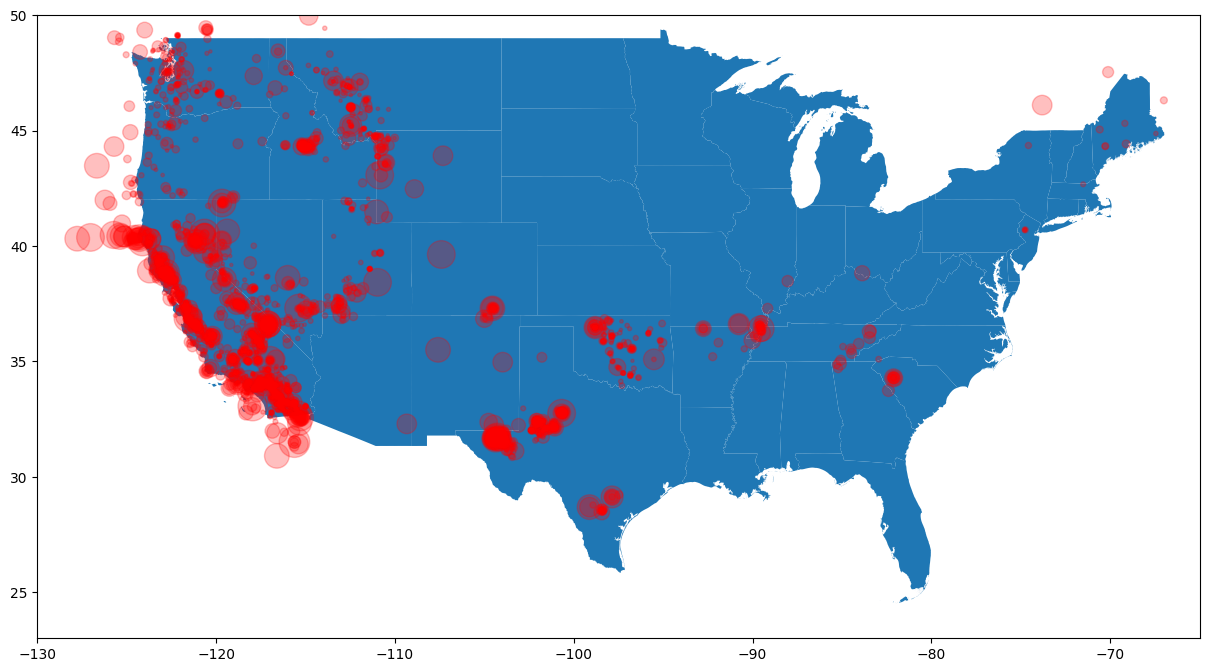

In [ ]:
import geopandas as gpd

ax = df_states.to_crs("EPSG:4326").plot(figsize = (15, 15))
ax.set_xlim(-130, -65)
ax.set_ylim(23, 50)
df_low_magnitude['size'] = 10 ** df_low_magnitude['properties.mag']

gdf_low = gpd.GeoDataFrame(
    df_low_magnitude,
    geometry=gpd.points_from_xy(
        x=df_low_magnitude["geometry.coordinates"].str[0],
        y=df_low_magnitude["geometry.coordinates"].str[1]
    ),
    crs="EPSG:4326"
)

gdf_low.plot(ax=ax, color="red", alpha=0.25, markersize= df_low_magnitude['size']/2)

## Earthquakes of High Magnitude: 10.01.24 to Current

<ipython-input-21-55a124346b2f>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_high_magnitude['size'] = 10 ** df_high_magnitude['properties.mag']


<Axes: >

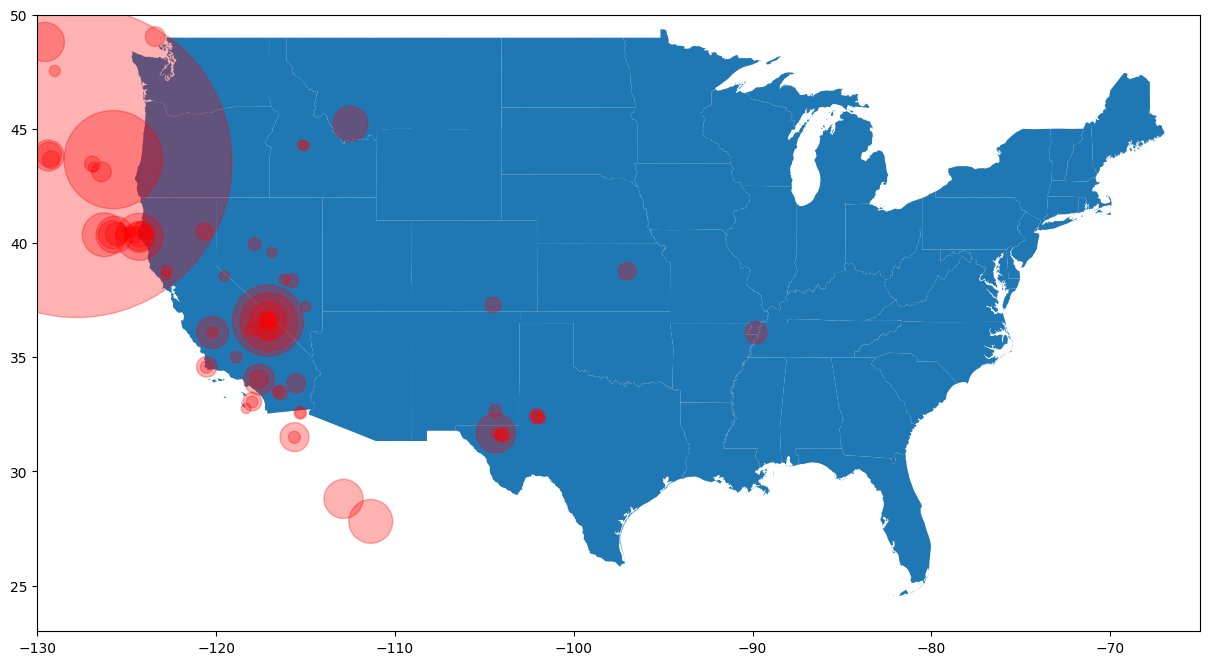

In [ ]:
import geopandas as gpd

ax = df_states.to_crs("EPSG:4326").plot(figsize = (15, 15))
ax.set_xlim(-130, -65)
ax.set_ylim(23, 50)
df_high_magnitude['size'] = 10 ** df_high_magnitude['properties.mag']

gdf_high = gpd.GeoDataFrame(
    df_high_magnitude,
    geometry=gpd.points_from_xy(
        x=df_high_magnitude["geometry.coordinates"].str[0],
        y=df_high_magnitude["geometry.coordinates"].str[1]
    ),
    crs="EPSG:4326"
)

gdf_high.plot(ax=ax, color="red", alpha=0.3, markersize= df_high_magnitude['size']/20)

### A Summary of the Data
Most of the earthquakes (particularly high magnitude ones) are found across a rough line that cuts through California, as well as some of Washington and Oregon. Oklahoma and Montana also are hotspots for smaller earthquakes within this last month. Other smaller collections include Arkansas, Tennessee, Texas, Wyoming, and Utah.

Two conclusions can be made from this, both of which are fairly straightforward.
1. Active fault lines can be approximated from locations with high activity with a linear spacial pattern.
2. Some states, far more than others, need resources to deal with crises, such as government funding for disaster relief, insurance, and reinforcements in infrastructure to prevent major damage.